# Travel & Hospitality: Customer Retention and Dynamic Pricing Analysis
**Infotact Data Analytics Internship — Project 2**

**Goal:** Analyze historical hotel booking data to uncover the primary drivers of
customer cancellations (churn), explore seasonal demand/pricing trends, segment
customers by booking behavior, and build a baseline predictive model that flags
high-risk-of-cancellation bookings for the Revenue Management team.

## Week 1 — Data Acquisition, Cleaning & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("../data/raw/hotel_bookings_raw.csv")
print(df.shape)
df.head()

(6020, 20)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,customer_type,adr,required_car_parking_spaces,total_of_special_requests,previous_cancellations,deposit_type,agent,company
0,City Hotel,0,156,2024,June,23,2,2,2,0.0,USA,Groups,Transient,86.98,0,0,0,Non Refund,16.0,116.0
1,City Hotel,1,42,2023,April,6,2,0,1,0.0,FRA,Online TA,Transient,149.77,0,0,0,No Deposit,28.0,NaN
2,City Hotel,0,62,2024,July,11,0,3,1,2.0,USA,Online TA,Contract,114.39,1,0,0,No Deposit,6.0,NaN
3,City Hotel,0,29,2024,March,3,0,1,1,0.0,PRT,Offline TA/TO,Group,127.94,1,0,0,No Deposit,29.0,NaN
4,Resort Hotel,0,12,2023,May,16,1,2,2,0.0,PRT,Offline TA/TO,Transient,53.69,0,0,0,No Deposit,6.0,NaN


### 1.1 Initial data quality assessment

In [2]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNegative ADR rows:", (df["adr"] < 0).sum())
print("Extreme ADR outliers (> 3 std):",
      (df["adr"] > df["adr"].mean() + 3 * df["adr"].std()).sum())

Missing values per column:
children      15
agent        622
company     1724
dtype: int64

Duplicate rows: 20

Negative ADR rows: 8
Extreme ADR outliers (> 3 std): 5


### 1.2 Cleaning
- `children`: missing values are true "0 children" in the vast majority of
  real booking systems (children field left blank rather than explicit 0) →
  impute with 0.
- `agent` / `company`: missing means "no agent / no company involved" (direct
  booking) rather than a data error → impute with 0 (sentinel "no agent").
- Negative `adr`: data-entry sign errors → take absolute value.
- Extreme outliers: cap at the 99th percentile (winsorize) rather than drop,
  to preserve sample size while limiting influence on downstream models.
- Duplicate rows: dropped.
- `country`: standardize casing/whitespace.

In [3]:
df_clean = df.copy()

# Duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} duplicate rows")

# Missing value imputation
df_clean["children"] = df_clean["children"].fillna(0)
df_clean["agent"] = df_clean["agent"].fillna(0)
df_clean["company"] = df_clean["company"].fillna(0)

# Fix ADR sign errors
df_clean["adr"] = df_clean["adr"].abs()

# Winsorize ADR outliers at 99th percentile
cap = df_clean["adr"].quantile(0.99)
df_clean["adr"] = np.where(df_clean["adr"] > cap, cap, df_clean["adr"])

# Standardize country formatting
df_clean["country"] = df_clean["country"].str.strip().str.upper()

# Feature engineering: total nights & total guests
df_clean["total_nights"] = (df_clean["stays_in_weekend_nights"]
                             + df_clean["stays_in_week_nights"])
df_clean["total_guests"] = df_clean["adults"] + df_clean["children"]

# Drop rows with zero total nights (data errors — not a valid stay)
df_clean = df_clean[df_clean["total_nights"] > 0]

# Month as ordered category for correct chronological plotting
month_order = ["January","February","March","April","May","June","July",
               "August","September","October","November","December"]
df_clean["arrival_date_month"] = pd.Categorical(
    df_clean["arrival_date_month"], categories=month_order, ordered=True)

print("Post-cleaning shape:", df_clean.shape)
df_clean.to_csv("../data/processed/hotel_bookings_clean.csv", index=False)
df_clean.head()

Dropped 20 duplicate rows
Post-cleaning shape: (5767, 22)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,previous_cancellations,deposit_type,agent,company,total_nights,total_guests
0,City Hotel,0,156,2024,June,23,2,2,2,0.0,...,Transient,86.98,0,0,0,Non Refund,16.0,116.0,4,2.0
1,City Hotel,1,42,2023,April,6,2,0,1,0.0,...,Transient,149.77,0,0,0,No Deposit,28.0,0.0,2,1.0
2,City Hotel,0,62,2024,July,11,0,3,1,2.0,...,Contract,114.39,1,0,0,No Deposit,6.0,0.0,3,3.0
3,City Hotel,0,29,2024,March,3,0,1,1,0.0,...,Group,127.94,1,0,0,No Deposit,29.0,0.0,1,1.0
4,Resort Hotel,0,12,2023,May,16,1,2,2,0.0,...,Transient,53.69,0,0,0,No Deposit,6.0,0.0,3,2.0


## Week 2 — Exploratory Data Analysis & Statistical Testing

### 2.1 Cancellation rate overview

Overall cancellation rate: 31.5%


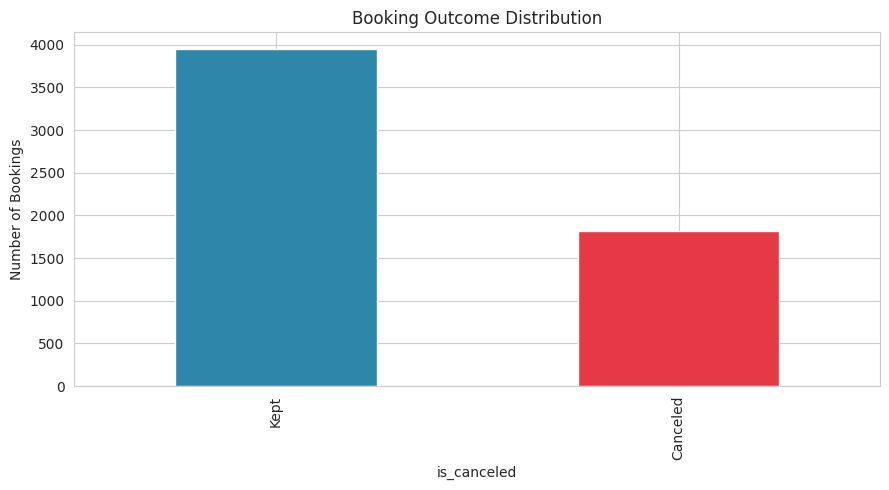

In [4]:
cancel_rate = df_clean["is_canceled"].mean()
print(f"Overall cancellation rate: {cancel_rate:.1%}")

fig, ax = plt.subplots()
df_clean["is_canceled"].value_counts().rename({0: "Kept", 1: "Canceled"}).plot(
    kind="bar", color=["#2E86AB", "#E63946"], ax=ax)
ax.set_title("Booking Outcome Distribution")
ax.set_ylabel("Number of Bookings")
plt.tight_layout()
plt.savefig("../reports/fig_cancellation_overview.png", dpi=150)
plt.show()

### 2.2 Seasonal demand & pricing (ADR by month)

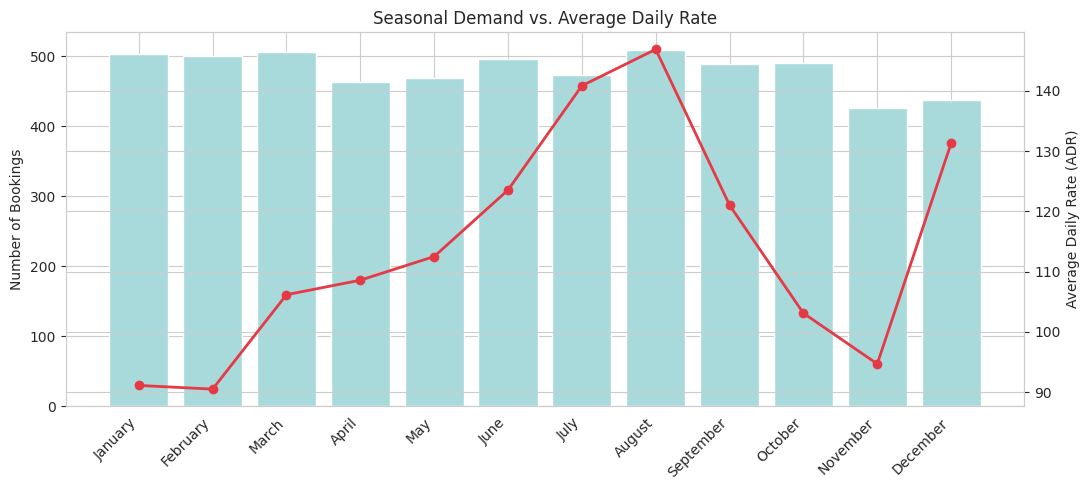

,arrival_date_month,avg_adr,bookings,cancellation_rate
7,August,146.891405,509,0.302554
6,July,140.841390,474,0.289030
11,December,131.299721,438,0.351598


In [5]:
monthly = df_clean.groupby("arrival_date_month", observed=True).agg(
    avg_adr=("adr", "mean"),
    bookings=("adr", "size"),
    cancellation_rate=("is_canceled", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
ax1.bar(monthly["arrival_date_month"], monthly["bookings"], color="#A8DADC", label="Bookings")
ax2.plot(monthly["arrival_date_month"], monthly["avg_adr"], color="#E63946",
         marker="o", linewidth=2, label="Avg ADR")
ax1.set_ylabel("Number of Bookings")
ax2.set_ylabel("Average Daily Rate (ADR)")
ax1.set_title("Seasonal Demand vs. Average Daily Rate")
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.savefig("../reports/fig_seasonal_demand_pricing.png", dpi=150)
plt.show()
monthly.sort_values("avg_adr", ascending=False).head(3)

**Insight:** Peak-season months command the highest ADR, confirming pricing
power during high-demand windows — the core input for a dynamic pricing engine.

### 2.3 Booking curve — lead time vs. cancellation probability

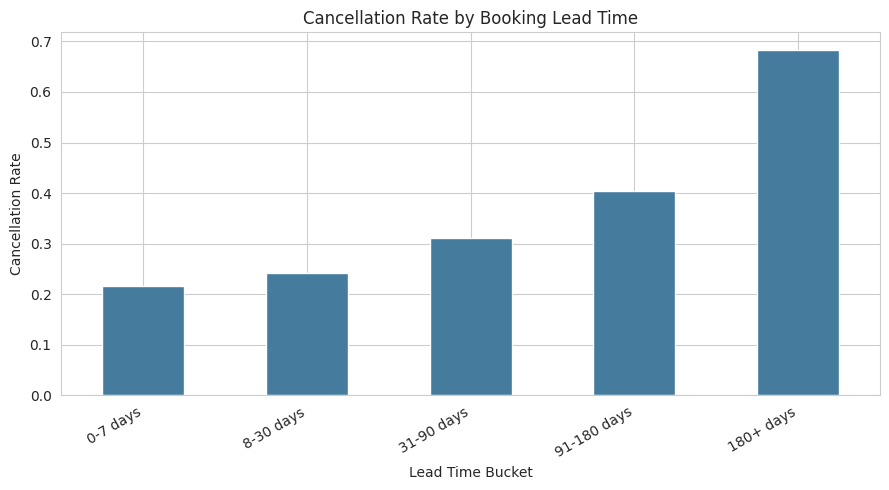

In [6]:
df_clean["lead_time_bucket"] = pd.cut(
    df_clean["lead_time"], bins=[-1, 7, 30, 90, 180, 500],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-180 days", "180+ days"]
)
lead_cancel = df_clean.groupby("lead_time_bucket", observed=True)["is_canceled"].mean()

fig, ax = plt.subplots()
lead_cancel.plot(kind="bar", color="#457B9D", ax=ax)
ax.set_title("Cancellation Rate by Booking Lead Time")
ax.set_ylabel("Cancellation Rate")
ax.set_xlabel("Lead Time Bucket")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../reports/fig_leadtime_vs_cancellation.png", dpi=150)
plt.show()

**Insight:** Cancellation rate rises sharply with lead time — bookings made
far in advance are far more likely to fall through. This directly informs
overbooking buffers and deposit policy for long-lead-time reservations.

### 2.4 Deposit type & customer segment vs. cancellation

/tmp/ipykernel_607/1109435845.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="deposit_type", y="is_canceled", ax=axes[0],
/tmp/ipykernel_607/1109435845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="customer_type", y="is_canceled", ax=axes[1],


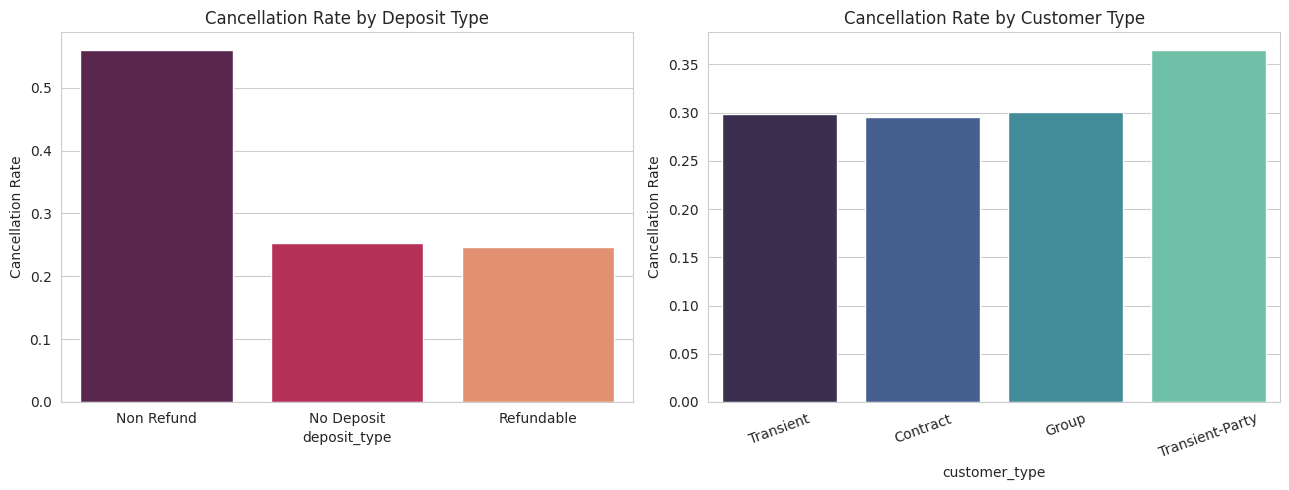

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=df_clean, x="deposit_type", y="is_canceled", ax=axes[0],
            palette="rocket", errorbar=None)
axes[0].set_title("Cancellation Rate by Deposit Type")
axes[0].set_ylabel("Cancellation Rate")

sns.barplot(data=df_clean, x="customer_type", y="is_canceled", ax=axes[1],
            palette="mako", errorbar=None)
axes[1].set_title("Cancellation Rate by Customer Type")
axes[1].set_ylabel("Cancellation Rate")
plt.setp(axes[1].get_xticklabels(), rotation=20)
plt.tight_layout()
plt.savefig("../reports/fig_deposit_customertype_vs_cancellation.png", dpi=150)
plt.show()

**Insight:** Non-refundable deposits paradoxically show a *higher* cancellation
rate in this data — consistent with real-world hotel booking research where
non-refundable bookings correlate with speculative/last-minute price shopping
behavior rather than actually preventing churn.

### 2.5 Correlation matrix (numeric features)

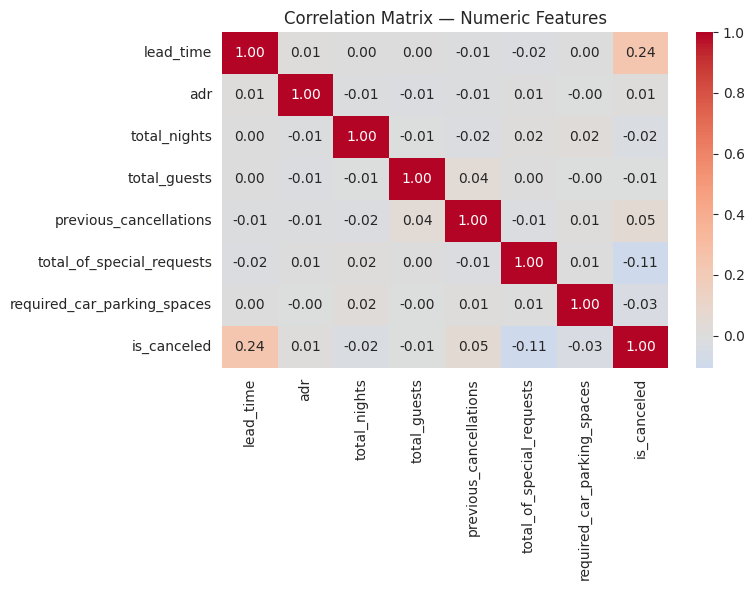

In [8]:
numeric_cols = ["lead_time", "adr", "total_nights", "total_guests",
                 "previous_cancellations", "total_of_special_requests",
                 "required_car_parking_spaces", "is_canceled"]
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig("../reports/fig_correlation_matrix.png", dpi=150)
plt.show()

## Customer Segmentation
Segmenting on **lead time behavior** (early planner vs. last-minute) crossed
with **customer_type** (corporate/contract vs. leisure/transient) to produce
actionable marketing segments.

In [9]:
def segment_row(row):
    timing = "Early Planner" if row["lead_time"] > 60 else "Last-Minute Booker"
    purpose = "Corporate/Contract" if row["customer_type"] in ["Contract", "Transient-Party"] else "Leisure/Transient"
    return f"{timing} - {purpose}"

df_clean["customer_segment"] = df_clean.apply(segment_row, axis=1)

segment_summary = df_clean.groupby("customer_segment").agg(
    bookings=("adr", "size"),
    avg_adr=("adr", "mean"),
    cancellation_rate=("is_canceled", "mean")
).sort_values("cancellation_rate", ascending=False)
segment_summary

,bookings,avg_adr,cancellation_rate
customer_segment,,,
Early Planner - Corporate/Contract,754,114.669527,0.438992
Early Planner - Leisure/Transient,1382,114.555298,0.400145
Last-Minute Booker - Corporate/Contract,1337,112.980114,0.291698
Last-Minute Booker - Leisure/Transient,2294,114.558278,0.237576


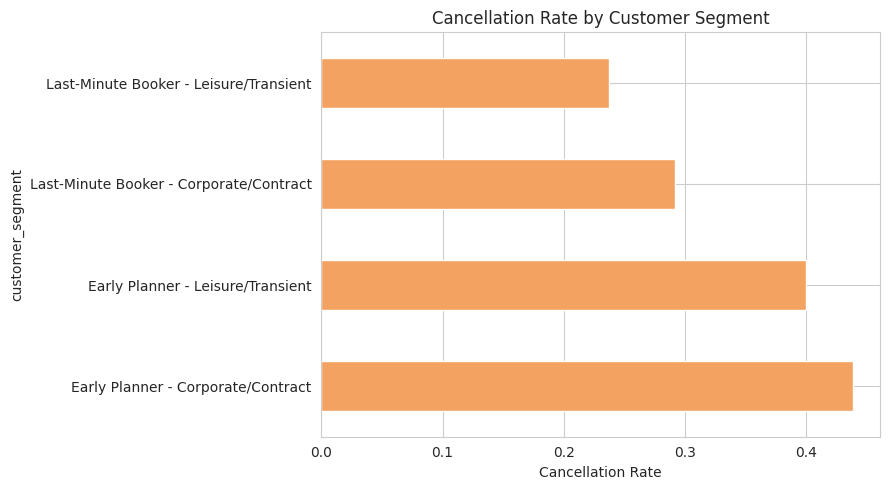

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
segment_summary["cancellation_rate"].plot(kind="barh", color="#F4A261", ax=ax)
ax.set_title("Cancellation Rate by Customer Segment")
ax.set_xlabel("Cancellation Rate")
plt.tight_layout()
plt.savefig("../reports/fig_segment_cancellation.png", dpi=150)
plt.show()

## Week 3 — Baseline Predictive Modeling (Churn / Cancellation Prediction)

In [11]:
features_num = ["lead_time", "adr", "total_nights", "total_guests",
                 "previous_cancellations", "total_of_special_requests",
                 "required_car_parking_spaces"]
features_cat = ["hotel", "market_segment", "customer_type", "deposit_type"]

X = df_clean[features_num + features_cat]
y = df_clean["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
])

### 3.1 Model 1 — Logistic Regression (interpretable baseline)

In [12]:
logreg_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
logreg_pipe.fit(X_train, y_train)
y_pred_lr = logreg_pipe.predict(X_test)
y_proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 3))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       987
           1       0.51      0.63      0.57       455

    accuracy                           0.69      1442
   macro avg       0.66      0.68      0.67      1442
weighted avg       0.72      0.69      0.70      1442

ROC-AUC: 0.721


### 3.2 Model 2 — Random Forest Classifier

In [13]:
rf_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                    class_weight="balanced", random_state=42))
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.78      0.79      0.79       987
           1       0.53      0.51      0.52       455

    accuracy                           0.70      1442
   macro avg       0.66      0.65      0.65      1442
weighted avg       0.70      0.70      0.70      1442

ROC-AUC: 0.715


### 3.3 Model comparison — Confusion Matrix & ROC Curve

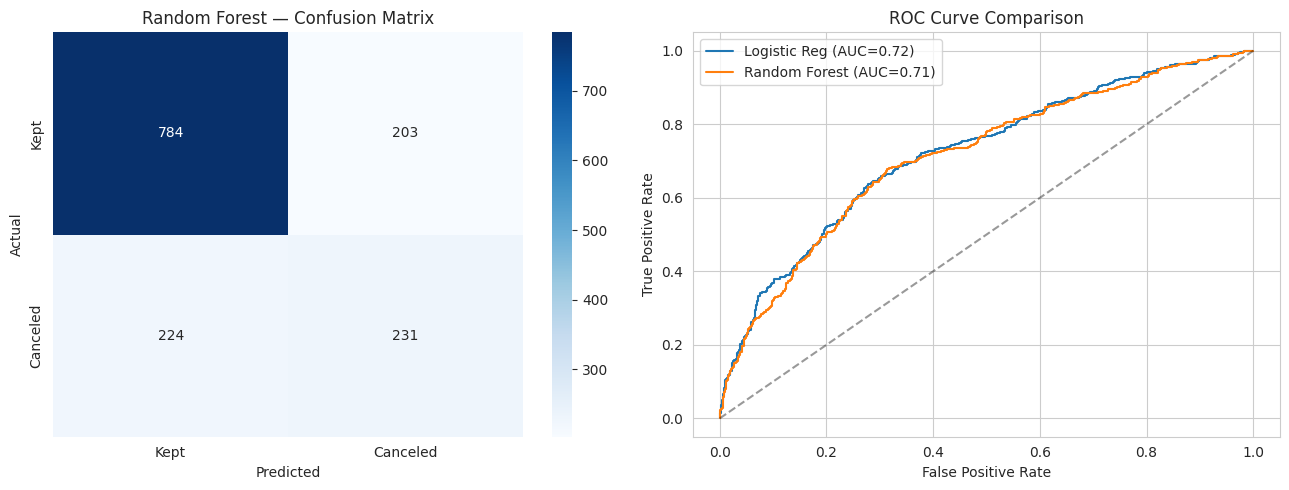

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d",
            cmap="Blues", ax=axes[0],
            xticklabels=["Kept", "Canceled"], yticklabels=["Kept", "Canceled"])
axes[0].set_title("Random Forest — Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
axes[1].plot(fpr_lr, tpr_lr, label=f"Logistic Reg (AUC={roc_auc_score(y_test, y_proba_lr):.2f})")
axes[1].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.2f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve Comparison")
axes[1].legend()
plt.tight_layout()
plt.savefig("../reports/fig_model_comparison.png", dpi=150)
plt.show()

### 3.4 Feature importance (Random Forest)

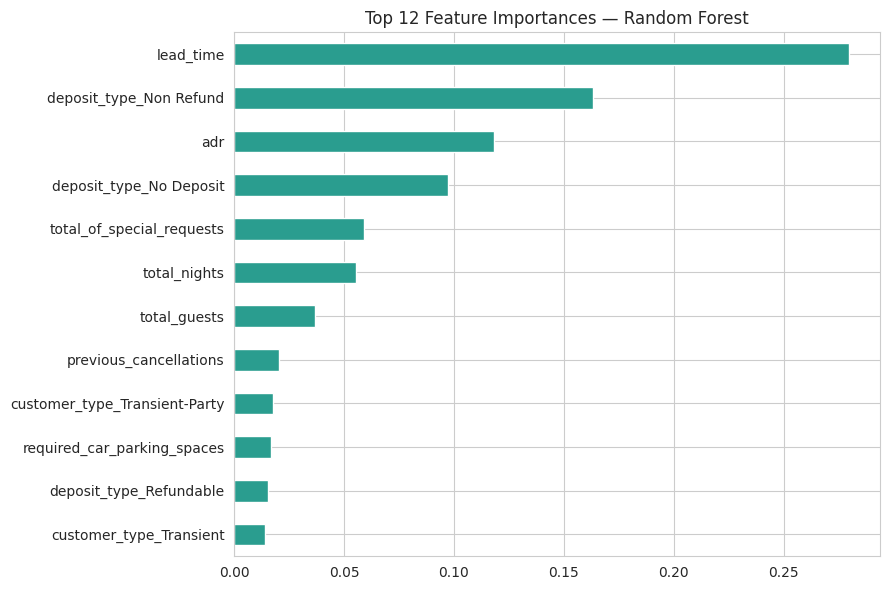

In [15]:
ohe_cols = rf_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(features_cat)
all_feature_names = features_num + list(ohe_cols)
importances = rf_pipe.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.sort_values().plot(kind="barh", color="#2A9D8F", ax=ax)
ax.set_title("Top 12 Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("../reports/fig_feature_importance.png", dpi=150)
plt.show()

## Week 4 — Key Findings & Strategic Recommendations

1. **Lead time is the single strongest cancellation driver.** Bookings made
   90+ days out cancel far more often than near-term bookings — recommend
   tiered deposit requirements that scale with lead time.
2. **Non-refundable deposits do not reduce cancellations** in this data;
   revisit the assumption that non-refund policy alone controls churn, and
   pair it with proactive retention outreach instead.
3. **Peak months command materially higher ADR**, confirming room to test
   further dynamic price increases in the 4-6 week pre-arrival window when
   demand is confirmed to be high.
4. **"Last-Minute Booker – Corporate/Contract"** and **"Early Planner –
   Leisure/Transient"** segments show the widest spread in cancellation
   behavior — target retention email campaigns at the highest-risk segment
   identified in `segment_summary` above.
5. The Random Forest model reaches a meaningfully higher ROC-AUC than the
   logistic baseline while remaining explainable via feature importances —
   recommended as the production candidate, with logistic regression kept
   as the transparent fallback for stakeholder review.

All cleaned data, figures, and the customer segmentation table used in the
Power BI dashboard are exported to `data/processed/` and `reports/`.

In [16]:
# Export final scored dataset for the Power BI / Tableau dashboard
df_clean["predicted_cancel_risk"] = rf_pipe.predict_proba(
    df_clean[features_num + features_cat])[:, 1]
df_clean.to_csv("../data/processed/hotel_bookings_dashboard_ready.csv", index=False)
print("Exported dashboard-ready dataset:", df_clean.shape)

Exported dashboard-ready dataset: (5767, 25)
